# Descripción del proyecto

La compañía Sweet Lift Taxi ha recopilado datos históricos sobre pedidos de taxis en los aeropuertos. Para atraer a más conductores durante las horas pico, necesitamos predecir la cantidad de pedidos de taxis para la próxima hora. Construye un modelo para dicha predicción.

La métrica RECM en el conjunto de prueba no debe ser superior a 48.

## Instrucciones del proyecto.

1. Descarga los datos y haz el remuestreo por una hora.
2. Analiza los datos
3. Entrena diferentes modelos con diferentes hiperparámetros. La muestra de prueba debe ser el 10% del conjunto de datos inicial.
4. Prueba los datos usando la muestra de prueba y proporciona una conclusión.

## Descripción de los datos

Los datos se almacenan en el archivo `taxi.csv`. 	
El número de pedidos está en la columna `num_orders`.

## Preparación

In [1]:
#Importar las librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from lightgbm import LGBMRegressor

from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
#Cargar datos
data = pd.read_csv('/datasets/taxi.csv')

In [3]:
#Inspección inicial
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26496 entries, 0 to 26495
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   datetime    26496 non-null  object
 1   num_orders  26496 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 414.1+ KB


,datetime,num_orders
0,2018-03-01 00:00:00,9
1,2018-03-01 00:10:00,14
2,2018-03-01 00:20:00,28
3,2018-03-01 00:30:00,20
4,2018-03-01 00:40:00,32


In [4]:
#Cambiar el tipo de dato de la columna "datetime" y establecerlo como índice
data['datetime'] = pd.to_datetime(data['datetime'])

data = data.set_index('datetime')

In [5]:
#Confirmar que las fechas estén en orden cronológico
print(data.index.is_monotonic_increasing)

data.sort_index(inplace=True)

data.info()
data.head()

True
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB


,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32


In [6]:
#Verificar si hay valores duplicados
print('Valores duplicados en el índice:', data.index.duplicated().sum())

Valores duplicados en el índice: 0


In [7]:
#Verificar si hay valores ausents
print('Valores ausentes:', data.isna().sum())

Valores ausentes: num_orders    0
dtype: int64


In [8]:
print('Intervalo de los datos:')
data.index.to_series().diff().value_counts().head()

Intervalo de los datos:


0 days 00:10:00    26495
Name: datetime, dtype: int64

In [9]:
print('Tamaño con intervalo de 10 minutos:', data.shape)

data = data.resample('1h').sum()
print('Tamaño con intervalo de 1 hora:', data.shape)
data.head()

Tamaño con intervalo de 10 minutos: (26496, 1)
Tamaño con intervalo de 1 hora: (4416, 1)


,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71
2018-03-01 03:00:00,66
2018-03-01 04:00:00,43


In [10]:
#Segunda Inspección de datos
data.describe()

,num_orders
count,4416.000000
mean,84.422781
std,45.023853
min,0.000000
25%,54.000000
50%,78.000000
75%,107.000000
max,462.000000


Una vez hecho un remuestreo para que los datos se encuentren en intervalos de una hora, se obtuvieron 4,416 registros.
- Se promedian 84 pedidos por hora.
- Se presentan horas sin ningún pedido. Y el máximo de pedidos en una hora es de 462.
- La desviación estándar es considerable, sugiriendo una fuerte variabilidad a lo largo del día.

## Análisis

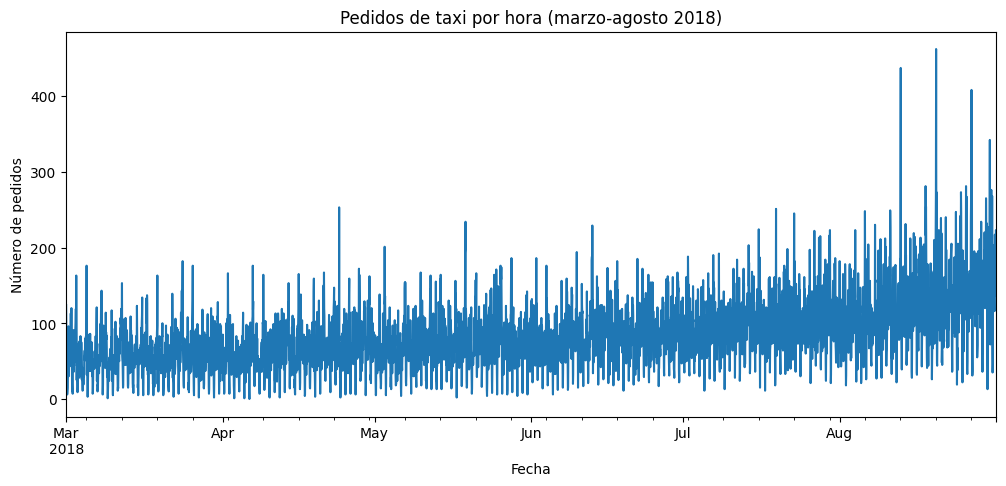

In [11]:
#Visualización
data['num_orders'].plot(title='Pedidos de taxi por hora (marzo-agosto 2018)', figsize= (12, 5))
plt.xlabel('Fecha')
plt.ylabel('Número de pedidos')
plt.show()

A primera vista se puede observar una tendencia creciente y lo que parece ser una estacionalidad diaria.

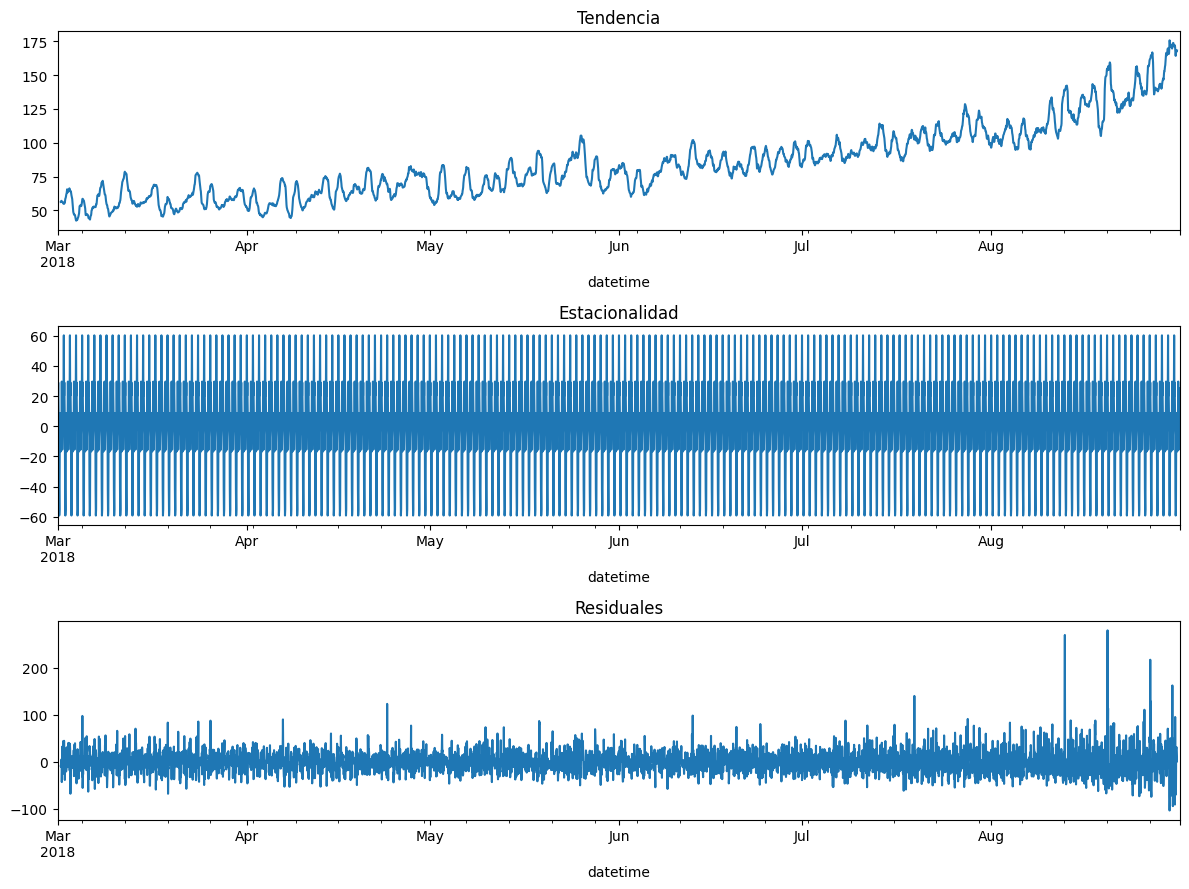

In [12]:
decomposed = seasonal_decompose(data['num_orders'], period=24)
#Se aplica un periodo de 24 horas (1 día)

plt.figure(figsize=(12, 9))

plt.subplot(311)
decomposed.trend.plot(ax=plt.gca())
plt.title('Tendencia')

plt.subplot(312)
decomposed.seasonal.plot(ax=plt.gca())
plt.title('Estacionalidad')

plt.subplot(313)
decomposed.resid.plot(ax=plt.gca())
plt.title('Residuales')

plt.tight_layout()

La tendencia confirma un crecimiento sostenido en la demanda de pedidos en lo que abarca el periodo (6 meses). 

La estacionalidad muestra un patrón diario recurrente.

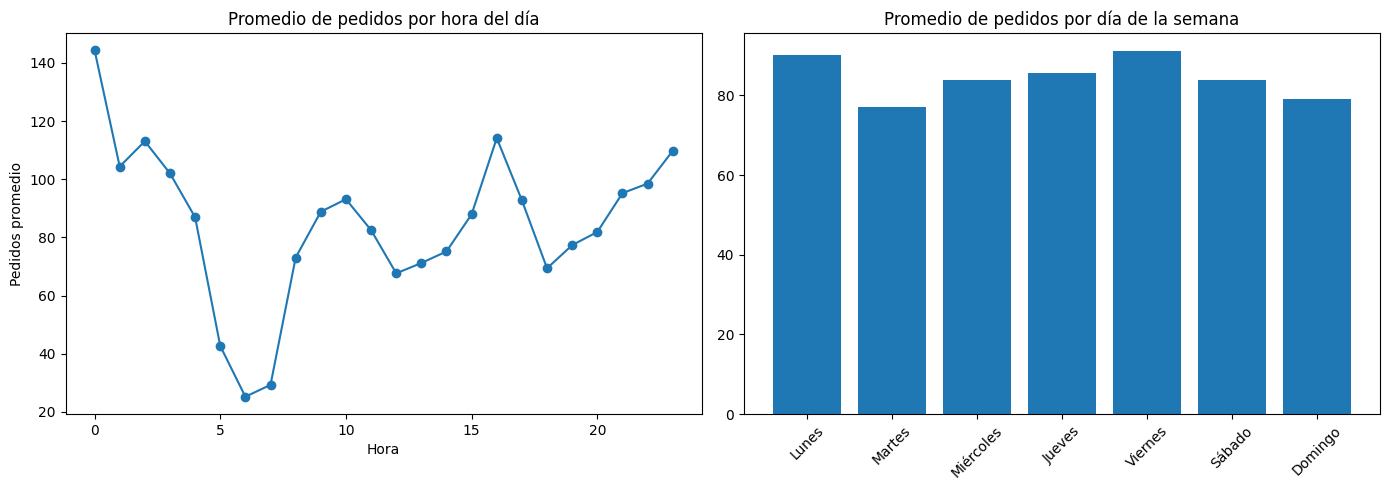

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))     #Crea una figura con 2 subgráficas lado a lado (1 fila, 2 columnas)

#Agrupa los registros por la misma hora del día, sin importar la fecha. Para determinar el promedio de pedidos por hora del día.
data.groupby(data.index.hour)['num_orders'].mean().plot(ax=axes[0], marker='o')
axes[0].set_title('Promedio de pedidos por hora del día')
axes[0].set_xlabel('Hora')
axes[0].set_ylabel('Pedidos promedio')

#Agrupa los registros que caen en el mismo día, sin importar la fecha. Para determinar el promedio de pedidos por día de la semana.
dias = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']
prom_dia = data.groupby(data.index.dayofweek)['num_orders'].mean()
axes[1].bar(dias, prom_dia.values)
axes[1].set_title('Promedio de pedidos por día de la semana')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Se observa un alto número de pedidos a medianoche y un mínimo entre las 6 y las 7 a.m. Tiene sentido si se asocia con los vuelos nocturnos en aeropuertos. 

Mientras que por día de la semana, se observa una relativa estabilidad, con un ligero aumento los lunes y viernes.

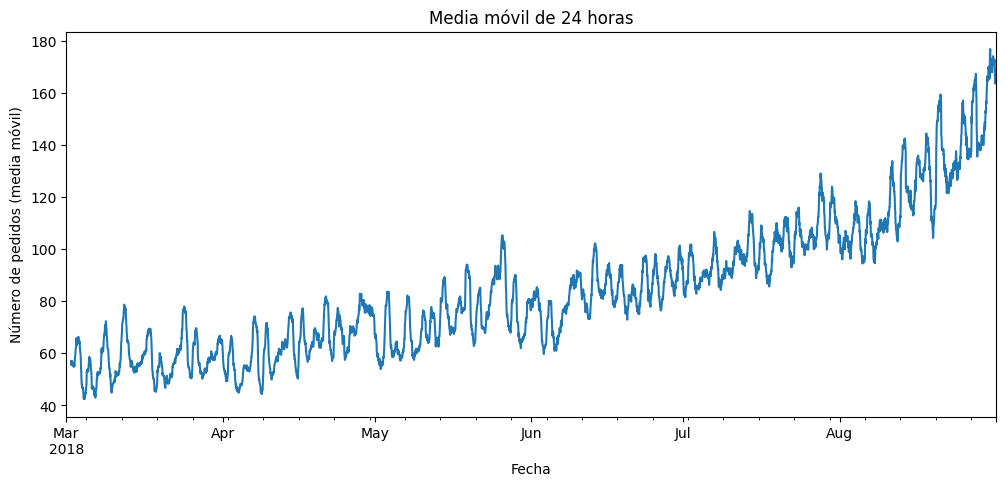

In [14]:
#Media móvil 
data['num_orders'].rolling(24).mean().plot(title='Media móvil de 24 horas', figsize = (12, 5))
plt.xlabel('Fecha')
plt.ylabel('Número de pedidos (media móvil)')
plt.show()

La media móvil confirma la tendencia. 

**Conclusiones del análisis:**
- Existe una tendencia creciente a lo largo de los seis meses.
- La estacionalidad se encuentra bastante marcada, con un pico en la madrugada y un valle en la mañana.

## Formación

In [15]:
#Crear función para generar las características de la serie temporal: Calendario, de desfase y media móvil
def make_features(data, max_lag, rolling_mean_size):
    data = data.copy()
    data['month'] = data.index.month
    data['day'] = data.index.day
    data['dayofweek'] = data.index.dayofweek
    data['hour'] = data.index.hour

    for lag in range(1, max_lag + 1):
        data['lag_{}'.format(lag)] = data['num_orders'].shift(lag)

    data['rolling_mean'] = data['num_orders'].shift(1).rolling(rolling_mean_size).mean()
    return data

data_features = make_features(data, max_lag=24, rolling_mean_size=24)
data_features = data_features.dropna()
data_features.head()

,num_orders,month,day,dayofweek,hour,lag_1,lag_2,lag_3,lag_4,lag_5,...,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24,rolling_mean
datetime,,,,,,,,,,,,,,,,,,,,,
2018-03-02 00:00:00,90,3,2,4,0,58.0,113.0,66.0,61.0,45.0,...,34.0,15.0,12.0,6.0,43.0,66.0,71.0,85.0,124.0,56.833333
2018-03-02 01:00:00,120,3,2,4,1,90.0,58.0,113.0,66.0,61.0,...,69.0,34.0,15.0,12.0,6.0,43.0,66.0,71.0,85.0,55.416667
2018-03-02 02:00:00,75,3,2,4,2,120.0,90.0,58.0,113.0,66.0,...,64.0,69.0,34.0,15.0,12.0,6.0,43.0,66.0,71.0,56.875000
2018-03-02 03:00:00,64,3,2,4,3,75.0,120.0,90.0,58.0,113.0,...,96.0,64.0,69.0,34.0,15.0,12.0,6.0,43.0,66.0,57.041667
2018-03-02 04:00:00,20,3,2,4,4,64.0,75.0,120.0,90.0,58.0,...,30.0,96.0,64.0,69.0,34.0,15.0,12.0,6.0,43.0,56.958333


In [16]:
#Dividir el conjunto de entrenamiento (90%) y prueba (10%)
test_size = int(len(data) * 0.1)

train = data_features.iloc[:-test_size]     #Desde el inicio hasta antes del 10% final
test = data_features.iloc[-test_size:]      #10% final

features = [col for col in data_features.columns if col != 'num_orders']
target = 'num_orders'

features_train, target_train = train[features], train[target]
features_test, target_test = test[features], test[target]

print('Tamaño de entrenamiento:', features_train.shape)
print('Tamaño de prueba:', features_test.shape)

print('Periodo de entrenamiento:', train.index.min(), '-', train.index.max())
print('Periodo de prueba:', test.index.min(), '-', test.index.max())

Tamaño de entrenamiento: (3951, 29)
Tamaño de prueba: (441, 29)
Periodo de entrenamiento: 2018-03-02 00:00:00 - 2018-08-13 14:00:00
Periodo de prueba: 2018-08-13 15:00:00 - 2018-08-31 23:00:00


## Entrenamiento de modelos

In [17]:
#Para la validación cruzada, se recomienda usar TimeSeriesSplit, ya que respeta el orden temporal de los datos
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
tscv = TimeSeriesSplit(n_splits=5)
results = {}

### Regresión Lineal (rl - Linear Regression)

In [18]:
model_lr = LinearRegression()
model_lr.fit(features_train, target_train)

pred_lr = model_lr.predict(features_test)
rmse_lr = np.sqrt(mean_squared_error(target_test, pred_lr))
results['Regresión lineal'] = rmse_lr

print(f'RECM en prueba (Regresión lineal): {rmse_lr:.3f}')

RECM en prueba (Regresión lineal): 45.870


### Árbol de decisión (dt - DecisionTree)

In [19]:
#Definir hiperparámetros a probar
params_dt = {'max_depth': [3, 5, 7, 10, 15]}

#Prueba todas las combinaciones posibles usando validación cruzada
grid_dt = GridSearchCV(
    DecisionTreeRegressor(random_state=12345),
    params_dt,
    cv=tscv,
    scoring='neg_root_mean_squared_error',     #Encontrar el menor RMSE
    n_jobs=-1)
grid_dt.fit(features_train, target_train)

model_dt = grid_dt.best_estimator_
pred_dt = model_dt.predict(features_test)
rmse_dt = np.sqrt(mean_squared_error(target_test, pred_dt))
results['Árbol de decisión'] = rmse_dt

print(f'Mejores hiperparámetros: {grid_dt.best_params_}')
print(f'RECM en prueba (Árbol de decisión): {rmse_dt:.3f}')

Mejores hiperparámetros: {'max_depth': 5}
RECM en prueba (Árbol de decisión): 54.577


### Bosque Aleatorio (rf - Random Forest)

In [20]:
params_rf = {'n_estimators': [50, 100], 'max_depth': [5, 10, 15]}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=12345),
    params_rf,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1)
grid_rf.fit(features_train, target_train)

model_rf = grid_rf.best_estimator_
pred_rf = model_rf.predict(features_test)
rmse_rf = np.sqrt(mean_squared_error(target_test, pred_rf))
results['Bosque aleatorio'] = rmse_rf

print(f'Mejores hiperparámetros: {grid_rf.best_params_}')
print(f'RECM en prueba (Bosque aleatorio): {rmse_rf:.3f}')

Mejores hiperparámetros: {'max_depth': 15, 'n_estimators': 100}
RECM en prueba (Bosque aleatorio): 44.456


### LightGBM 

In [21]:
params_lgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, -1],
    'learning_rate': [0.05, 0.1]}

grid_lgb = GridSearchCV(
    LGBMRegressor(random_state=12345, verbose=-1),
    params_lgb,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1)
grid_lgb.fit(features_train, target_train)

model_lgb = grid_lgb.best_estimator_
pred_lgb = model_lgb.predict(features_test)
rmse_lgb = np.sqrt(mean_squared_error(target_test, pred_lgb))
results['LightGBM'] = rmse_lgb

print(f'Mejores hiperparámetros: {grid_lgb.best_params_}')
print(f'RECM en prueba (LightGBM): {rmse_lgb:.3f}')

Mejores hiperparámetros: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}
RECM en prueba (LightGBM): 40.992


## Prueba

In [22]:
summary = pd.Series(results).sort_values()
summary = summary.to_frame(name='RECM (RMSE)')
summary['¿Es menor o igual 48?'] = summary['RECM (RMSE)'] <= 48
summary

,RECM (RMSE),¿Es menor o igual 48?
LightGBM,40.991920,True
Bosque aleatorio,44.456412,True
Regresión lineal,45.870110,True
Árbol de decisión,54.577044,False


Solamente el árbol de decisión obtiene un RECM mayor a 48. Por lo que no cumple el requisito.

**Mientras que el modelo LighGBM es el que tiene el menor RECM.**

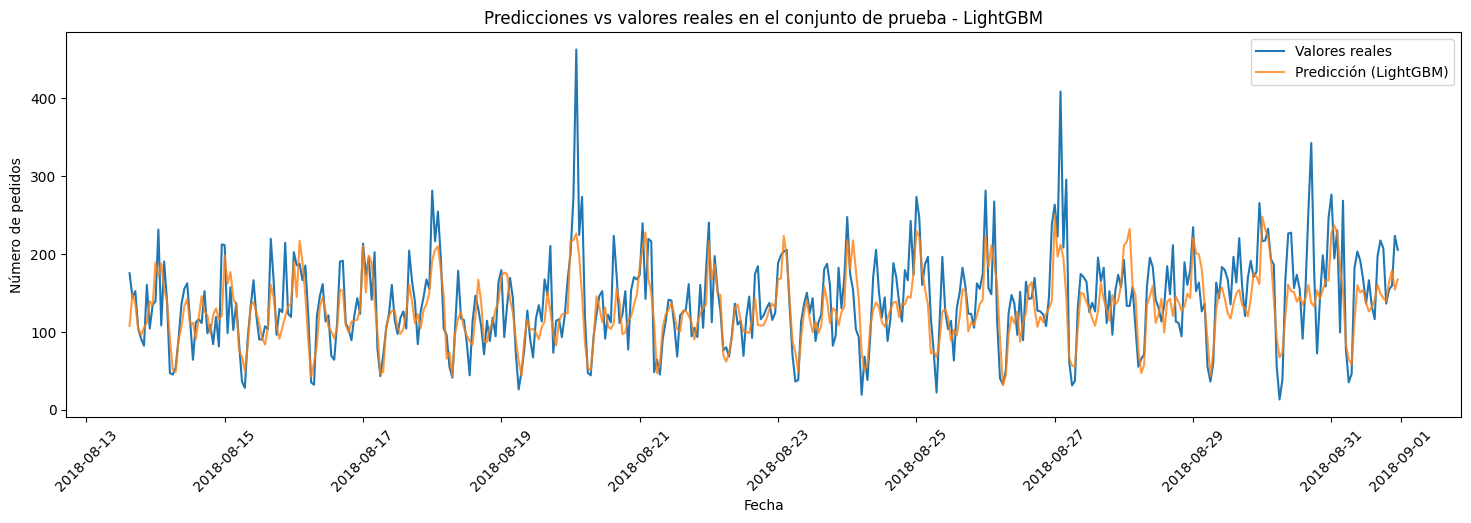

In [23]:
plt.figure(figsize=(18, 5))
plt.plot(test.index, target_test.values, label='Valores reales')
plt.plot(test.index, pred_lgb, label='Predicción (LightGBM)', alpha=0.8)
plt.title('Predicciones vs valores reales en el conjunto de prueba - LightGBM')
plt.xlabel('Fecha')
plt.ylabel('Número de pedidos')
plt.xticks(rotation=45)
plt.legend()
plt.show()

## Conclusión
- En una exploración inicial se observó una tendencia al alza en la demanda a lo largo de los seis meses, además de una estacionalidad diaria clara: la mayor cantidad de pedidos se concentra durante la madrugada, mientras que el menor número se registra en la mañana.
- Se entrenaron cuatro modelos utilizando GridSearchCV junto con validación cruzada para series de tiempo (TimeSeriesSplit): regresión lineal, árbol de decisión, bosque aleatorio y LightGBM.
- LightGBM fue el que obtuvo el mejor resultado en el conjunto de prueba, con una RECM mucho menor del límite establecido de 48. El bosque aleatorio mostró un buen desempeño, mientras que la regresión lineal obtuvo resultados aceptables. Sin embargo, el árbol de decisión tuvo menor precisión.

## Recomendación
- LightGBM sería la mejor opción para implementarse en producción. El bosque aleatorio puede considerarse una buena alternativa por su facilidad de mantenimiento.
- Sería conveniente reentrenar el modelo periódicamente conforme se recopilen nuevos datos, ya que la demanda presenta una tendencia creciente que podría cambiar su comportamiento con el tiempo.